# 06 — Veda: Full Multi-Axis Bias Analysis
*Political Bias Transfer in LLM-Generated Training Data — EMNLP 2026*

---

## What this notebook adds over `05_MultiAxisBias_Analysis.ipynb`

| Feature | 05 | 06 (this) |
|---|---|---|
| BvT bias heatmap (synth vs mixed) | ✓ | ✓ |
| Per-target F1 drop heatmap | ✓ | ✓ |
| F1 by condition grouped bar | ✓ | ✓ |
| Mitigation effectiveness | ✓ | ✓ |
| Generator bias profile | ✓ | ✓ |
| Classifier susceptibility | ✓ | ✓ |
| Per-seed F1 variance | ✓ | ✓ |
| `_full` vs `_balanced` bias variant comparison | ✗ | **✓** |
| Bootstrap 95% CI on F1-proxy bias scores | ✗ | **✓** |
| 5-axis bias heatmap (qwen-2.5-7b available) | ✗ | **✓** |
| F1-proxy class distribution shift Δ(t,c) | ✗ | **✓** |
| Paired t-test (synth vs real) per (clf, gen) | ✗ | **✓** |
| Cross-generator lean ranking & Spearman ρ | ✗ | **✓** |
| Calibration gap documentation (ECE, Brier) | ✗ | **✓** |
| Input data validation | ✗ | **✓** |

## Scope notes
- **Generators:** 7 (expanded from locked-scope 2: GPT-4o-mini + Llama-3-Instruct)
- **Classifiers:** 3 — RoBERTa, DeBERTaV3, BERTweet (expanded from locked-scope 2; Llama-3-base classifier pending Colab A100 run)
- **Multi-axis data:** Only qwen-2.5-7b has all 5 axes saved; full 21-combo multi-axis requires re-running fine-tuning notebooks with prediction export enabled

## All outputs (saved to `results/` and `results/figures/`)
```
paper_summary.csv               paper_summary_with_ci.csv
generator_lean_profile.csv      06_ttest_pvals.csv
figures/06_bias_heatmap_synth_vs_mixed.png    figures/06_bias_heatmap_4panel.png
figures/06_f1_drop_per_target.png             figures/06_bias_ci_errorbar.png
figures/06_f1_real_vs_synth_vs_mixed.png      figures/06_bias_5axis_qwen.png
figures/06_bias_mitigation.png                figures/06_delta_f1_proxy.png
figures/06_generator_bias_profile.png         figures/06_pval_heatmap.png
figures/06_classifier_susceptibility.png      figures/06_generator_lean_ranking.png
figures/06_per_seed_variance.png
```


## 1. Imports + Constants


In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pathlib
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

# ── Path setup ────────────────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = pathlib.Path('/content/drive/MyDrive/Proj/PoliticalBiasProject')
except Exception:
    PROJECT_DIR = pathlib.Path('.')

RESULTS_DIR = PROJECT_DIR / 'results'
FIG_DIR = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
TARGETS     = ['Donald Trump', 'Joe Biden', 'Bernie Sanders']
CONDITIONS  = ['real', 'synth', 'mixed']
SEEDS       = [42, 123, 7]
RUN_TAG     = 'real+synth+mixed'

CLF_ORDER = ['roberta', 'debertav3', 'bertweet']
GEN_ORDER = ['gpt-4o-mini', 'gpt-5.4-mini', 'mistral-7b', 'qwen-2.5-7b',
             'gemma-2-9b', 'llama-3.1-8b', 'llama-3.2-3b']

# Bias axes from combined_summary_multiaxis.csv
BIAS_AXES = ['B_vs_T', 'Ber_vs_T', 'B_vs_Ber', 'Left_vs_T', 'Estab_vs_Outsider']
AXIS_LABELS = {
    'B_vs_T':            'Biden vs Trump',
    'Ber_vs_T':          'Bernie vs Trump',
    'B_vs_Ber':          'Biden vs Bernie',
    'Left_vs_T':         'Left-lean vs Trump',
    'Estab_vs_Outsider': 'Establishment vs Outsider',
}

matplotlib.rcParams.update({
    'font.size': 10,
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

def savefig(name):
    plt.savefig(FIG_DIR / name, bbox_inches='tight')
    print(f'  → {FIG_DIR / name}')

print('Setup complete. PROJECT_DIR =', PROJECT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete. PROJECT_DIR = /content/drive/MyDrive/Proj/PoliticalBiasProject


## 2. Data Loading + Validation


In [2]:
# ── 2a. combined_summary.csv ──────────────────────────────────────────────────
summary = pd.read_csv(RESULTS_DIR / 'combined_summary.csv')

# Validation
expected_combos = {(clf, gen) for clf in CLF_ORDER for gen in GEN_ORDER}
actual_combos   = set(zip(summary['classifier'], summary['generator']))
missing = expected_combos - actual_combos
extra   = actual_combos - expected_combos

assert summary.shape[0] == 21, f'Expected 21 rows, got {summary.shape[0]}'

key_cols = ['bias_synth_full', 'bias_mixed_full', 'real_f1', 'synth_f1', 'mixed_f1']
nans = summary[key_cols].isna().sum()
if nans.any():
    print(f'WARNING: NaN values found:\n{nans[nans > 0]}')
else:
    print('✓ No NaN in key columns')
if missing:
    print(f'WARNING: Missing combos: {missing}')
else:
    print(f'✓ All 21 (classifier, generator) combos present')
if extra:
    print(f'NOTE: Unexpected combos: {extra}')

# Categorical ordering
summary['classifier'] = pd.Categorical(summary['classifier'], categories=CLF_ORDER, ordered=True)
summary['generator']  = pd.Categorical(summary['generator'],  categories=GEN_ORDER,  ordered=True)
summary = summary.sort_values(['classifier', 'generator']).reset_index(drop=True)

print(f'\ncombined_summary.csv: {summary.shape[0]} rows × {summary.shape[1]} cols')
print(summary[['classifier','generator','real_f1','synth_f1','mixed_f1',
               'bias_synth_full','bias_mixed_full']].to_string(index=False))

# ── 2b. combined_summary_multiaxis.csv ────────────────────────────────────────
multiaxis_path = RESULTS_DIR / 'combined_summary_multiaxis.csv'
if multiaxis_path.exists():
    multiaxis = pd.read_csv(multiaxis_path)
    multiaxis['classifier'] = pd.Categorical(multiaxis['classifier'], categories=CLF_ORDER, ordered=True)
    multiaxis = multiaxis.sort_values('classifier').reset_index(drop=True)
    print(f'\ncombined_summary_multiaxis.csv: {multiaxis.shape[0]} rows × {multiaxis.shape[1]} cols')
    print(f'  Coverage: {multiaxis[["classifier","generator"]].to_dict("records")}')
    print(f'  NOTE: Only qwen-2.5-7b has all 5 axes. Full 21-combo analysis requires')
    print(f'        re-running fine-tuning notebooks with raw prediction export.')
else:
    multiaxis = None
    print('WARNING: combined_summary_multiaxis.csv not found — Section 6 will be skipped')

# ── 2c. Per-seed test_metrics.csv ─────────────────────────────────────────────
per_seed_rows = []
for clf in CLF_ORDER:
    for gen in GEN_ORDER:
        tm_path = RESULTS_DIR / clf / gen / RUN_TAG / 'test_metrics.csv'
        if not tm_path.exists():
            print(f'  WARNING: missing {tm_path}')
            continue
        df = pd.read_csv(tm_path)
        df['classifier'] = clf
        df['generator']  = gen
        per_seed_rows.append(df)

if per_seed_rows:
    per_seed = pd.concat(per_seed_rows, ignore_index=True)
    per_seed['classifier'] = pd.Categorical(per_seed['classifier'], categories=CLF_ORDER, ordered=True)
    per_seed['generator']  = pd.Categorical(per_seed['generator'],  categories=GEN_ORDER,  ordered=True)
    print(f'\nper_seed: {len(per_seed)} rows from {len(per_seed_rows)} combos')
    print(f'  Columns: {list(per_seed.columns)}')
else:
    per_seed = pd.DataFrame()
    print('WARNING: No per-seed metrics found')


✓ No NaN in key columns
✓ All 21 (classifier, generator) combos present

combined_summary.csv: 21 rows × 14 cols
classifier    generator  real_f1  synth_f1  mixed_f1  bias_synth_full  bias_mixed_full
   roberta  gpt-4o-mini    0.824     0.705     0.811            0.260            0.043
   roberta gpt-5.4-mini    0.824     0.697     0.809            0.238            0.052
   roberta   mistral-7b    0.824     0.678     0.818            0.213           -0.008
   roberta  qwen-2.5-7b    0.824     0.705     0.805            0.169            0.022
   roberta   gemma-2-9b    0.824     0.718     0.808            0.256            0.074
   roberta llama-3.1-8b    0.824     0.712     0.815            0.048            0.028
   roberta llama-3.2-3b    0.824     0.717     0.813           -0.122           -0.015
 debertav3  gpt-4o-mini    0.849     0.714     0.833            0.188           -0.001
 debertav3 gpt-5.4-mini    0.849     0.751     0.837            0.066           -0.018
 debertav3   mist

## 3. Reproduced Baseline (from `05`)
All 7 original figures reproduced here. Outputs use `06_` prefix to avoid overwriting `05` outputs.


### 3a. Paper Table 2 — Headline summary


In [3]:
paper = summary[['classifier','generator','real_f1','synth_f1','mixed_f1',
                    'trump_synth_dF1','biden_synth_dF1','bernie_synth_dF1',
                    'bias_synth_full','bias_mixed_full']].copy()
paper.columns = ['classifier','generator','F1_real','F1_synth','F1_mixed',
                 'dF1_Trump','dF1_Biden','dF1_Bernie','BiasBvT_synth','BiasBvT_mixed']
paper.to_csv(RESULTS_DIR / 'paper_summary.csv', index=False)
print('paper_summary.csv saved.')
pd.set_option('display.width', 140)
print(paper.to_string(index=False))


paper_summary.csv saved.
classifier    generator  F1_real  F1_synth  F1_mixed  dF1_Trump  dF1_Biden  dF1_Bernie  BiasBvT_synth  BiasBvT_mixed
   roberta  gpt-4o-mini    0.824     0.705     0.811     -0.169     -0.077      -0.109          0.260          0.043
   roberta gpt-5.4-mini    0.824     0.697     0.809     -0.170     -0.109      -0.098          0.238          0.052
   roberta   mistral-7b    0.824     0.678     0.818     -0.206     -0.110      -0.118          0.213         -0.008
   roberta  qwen-2.5-7b    0.824     0.705     0.805     -0.148     -0.115      -0.085          0.169          0.022
   roberta   gemma-2-9b    0.824     0.718     0.808     -0.135     -0.109      -0.065          0.256          0.074
   roberta llama-3.1-8b    0.824     0.712     0.815     -0.147     -0.105      -0.073          0.048          0.028
   roberta llama-3.2-3b    0.824     0.717     0.813     -0.150     -0.092      -0.069         -0.122         -0.015
 debertav3  gpt-4o-mini    0.849     0.

### 3b. Bias heatmap — BvT synth vs mixed


  → /content/drive/MyDrive/Proj/PoliticalBiasProject/results/figures/06_bias_heatmap_synth_vs_mixed.png


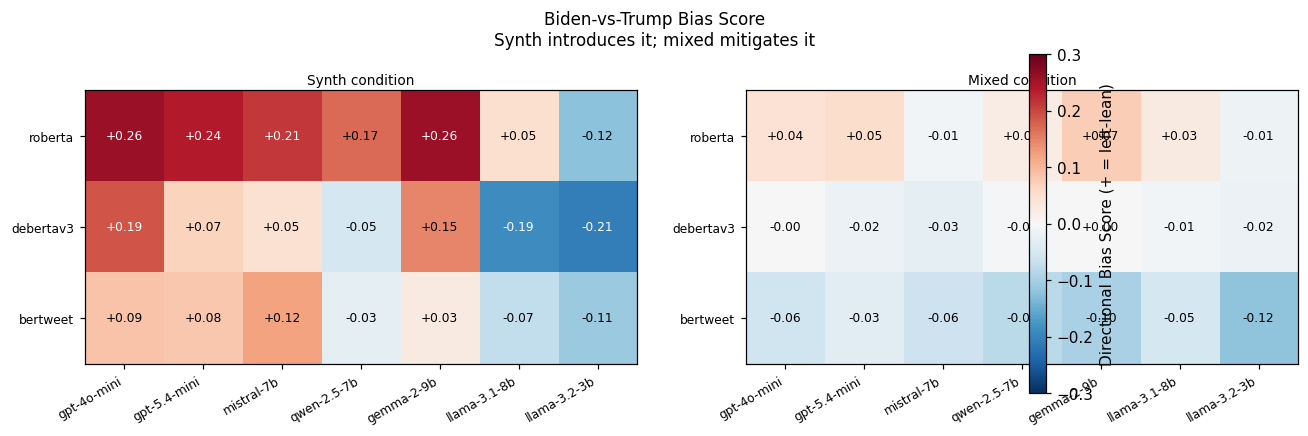

In [4]:
def bias_heatmap(ax, pivot_data, title, vmax=None):
    if vmax is None:
        vmax = max(0.3, pivot_data.abs().max().max() * 1.1)
    im = ax.imshow(pivot_data, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(pivot_data.columns)))
    ax.set_xticklabels(pivot_data.columns, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot_data.index)))
    ax.set_yticklabels(pivot_data.index, fontsize=8)
    for i in range(len(pivot_data.index)):
        for j in range(len(pivot_data.columns)):
            v = pivot_data.iloc[i, j]
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    fontsize=8, color='white' if abs(v) > vmax * 0.6 else 'black')
    ax.set_title(title, fontsize=9, pad=4)
    return im

vmax_bias = max(0.3, max(summary['bias_synth_full'].abs().max(),
                          summary['bias_mixed_full'].abs().max()) * 1.1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes,
        ['bias_synth_full', 'bias_mixed_full'],
        ['Synth condition', 'Mixed condition']):
    pivot = summary.pivot_table(index='classifier', columns='generator', values=col)
    pivot = pivot.reindex(index=CLF_ORDER, columns=GEN_ORDER)
    im = bias_heatmap(ax, pivot, title, vmax=vmax_bias)

fig.colorbar(im, ax=axes, label='Directional Bias Score (+ = left-lean)')
fig.suptitle('Biden-vs-Trump Bias Score\nSynth introduces it; mixed mitigates it', fontsize=11)
plt.tight_layout()
savefig('06_bias_heatmap_synth_vs_mixed.png')
plt.show()


### 3c. Per-target F1 drop


  → /content/drive/MyDrive/Proj/PoliticalBiasProject/results/figures/06_f1_drop_per_target.png


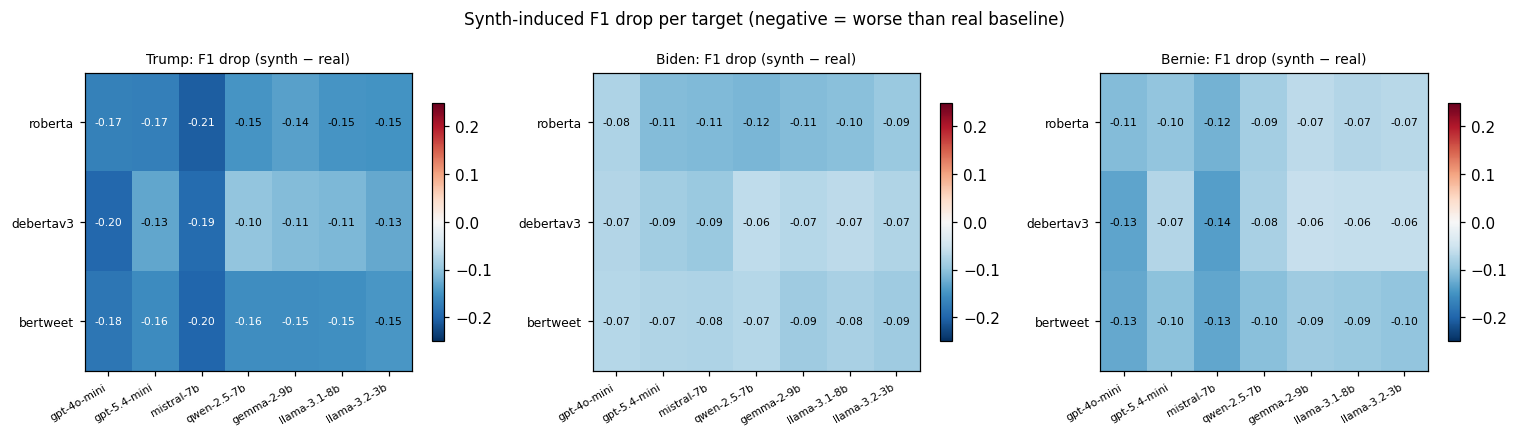

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, label) in zip(axes, [
        ('trump_synth_dF1', 'Trump'), ('biden_synth_dF1', 'Biden'), ('bernie_synth_dF1', 'Bernie')]):
    pivot = summary.pivot_table(index='classifier', columns='generator', values=col)
    pivot = pivot.reindex(index=CLF_ORDER, columns=GEN_ORDER)
    vmax = max(0.25, pivot.abs().max().max() * 1.1)
    im = ax.imshow(pivot, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(GEN_ORDER)))
    ax.set_xticklabels(GEN_ORDER, rotation=30, ha='right', fontsize=7)
    ax.set_yticks(range(len(CLF_ORDER)))
    ax.set_yticklabels(CLF_ORDER, fontsize=8)
    for i in range(len(CLF_ORDER)):
        for j in range(len(GEN_ORDER)):
            v = pivot.iloc[i, j]
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(v) > vmax * 0.6 else 'black')
    ax.set_title(f'{label}: F1 drop (synth − real)', fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Synth-induced F1 drop per target (negative = worse than real baseline)', fontsize=11)
plt.tight_layout()
savefig('06_f1_drop_per_target.png')
plt.show()


### 3d. F1 by condition


  → /content/drive/MyDrive/Proj/PoliticalBiasProject/results/figures/06_f1_real_vs_synth_vs_mixed.png


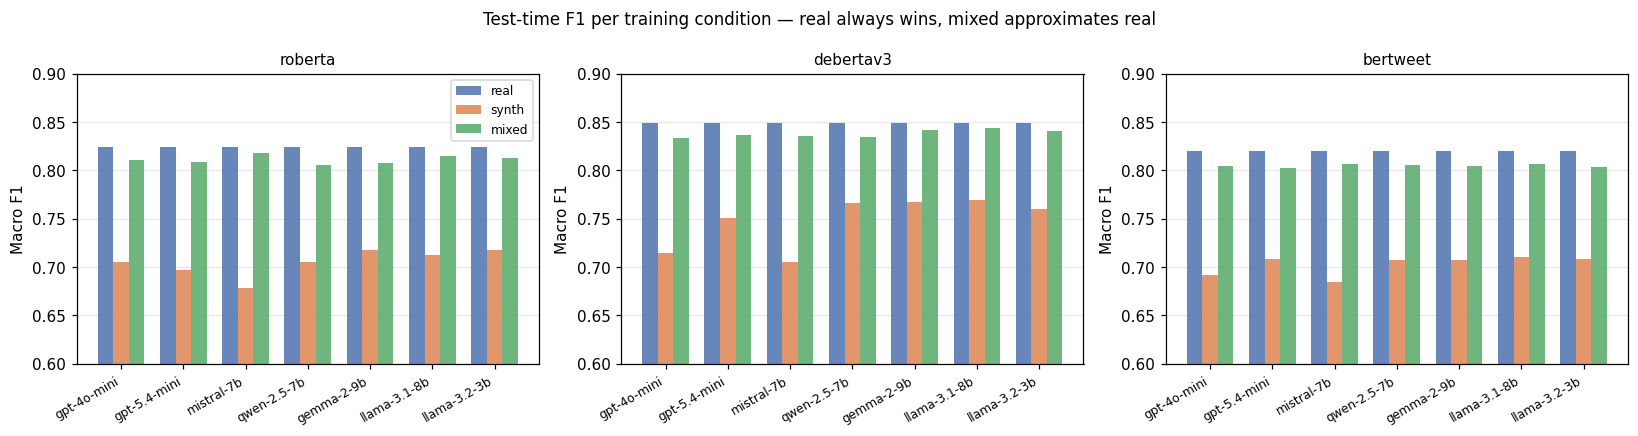

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'real': '#4c72b0', 'synth': '#dd8452', 'mixed': '#55a868'}
x = np.arange(len(GEN_ORDER))
w = 0.25

for ax, clf in zip(axes, CLF_ORDER):
    sub = summary[summary['classifier'] == clf].sort_values('generator')
    for i, (cond, col) in enumerate(zip(CONDITIONS, ['real_f1','synth_f1','mixed_f1'])):
        ax.bar(x + (i - 1) * w, sub[col], width=w, label=cond,
               color=colors[cond], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(GEN_ORDER, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0.60, 0.90)
    ax.set_ylabel('Macro F1')
    ax.set_title(clf, fontsize=10)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    if ax == axes[0]:
        ax.legend(fontsize=8)

fig.suptitle('Test-time F1 per training condition — real always wins, mixed approximates real', fontsize=11)
plt.tight_layout()
savefig('06_f1_real_vs_synth_vs_mixed.png')
plt.show()


### 3e. Bias mitigation effectiveness


  → /content/drive/MyDrive/Proj/PoliticalBiasProject/results/figures/06_bias_mitigation.png


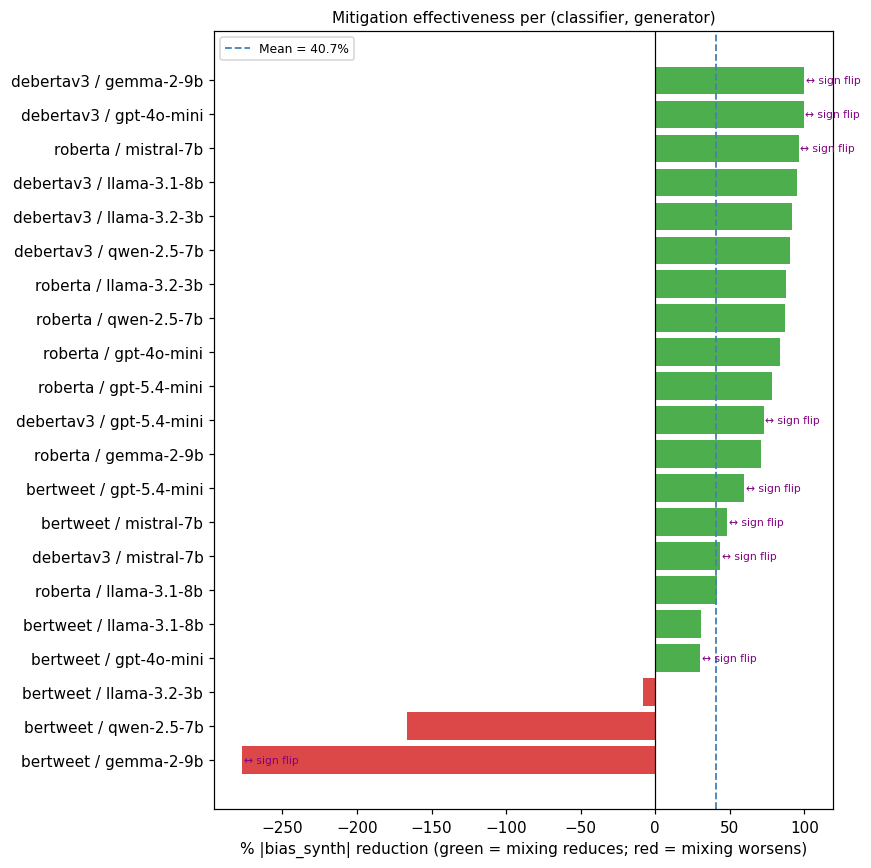

Mean bias reduction: 40.7%
Sign flips (mixing reverses bias direction): 9 / 21


In [7]:
mit = summary[['classifier','generator','bias_synth_full','bias_mixed_full']].copy()
mit['abs_synth']  = mit['bias_synth_full'].abs()
mit['abs_mixed']  = mit['bias_mixed_full'].abs()
mit['reduction']  = mit['abs_synth'] - mit['abs_mixed']
mit['sign_flip']  = np.sign(mit['bias_synth_full']) != np.sign(mit['bias_mixed_full'])
mit['pct_reduction'] = np.where(
    mit['abs_synth'] > 0,
    100 * mit['reduction'] / mit['abs_synth'],
    np.nan)
mit = mit.sort_values('pct_reduction', ascending=True)
mit['label'] = mit['classifier'].astype(str) + ' / ' + mit['generator'].astype(str)

colors_mit = ['#2ca02c' if v >= 0 else '#d62728' for v in mit['pct_reduction']]
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(mit['label'], mit['pct_reduction'], color=colors_mit, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('% |bias_synth| reduction (green = mixing reduces; red = mixing worsens)')
ax.set_title('Mitigation effectiveness per (classifier, generator)', fontsize=10)

# Mark sign-flip cases
for i, (_, row) in enumerate(mit.iterrows()):
    if row['sign_flip']:
        ax.text(row['pct_reduction'] + 1, i, '↔ sign flip', va='center', fontsize=7, color='purple')

mean_red = mit['pct_reduction'].mean()
ax.axvline(mean_red, color='steelblue', linewidth=1.2, linestyle='--', label=f'Mean = {mean_red:.1f}%')
ax.legend(fontsize=8)
plt.tight_layout()
savefig('06_bias_mitigation.png')
plt.show()
print(f'Mean bias reduction: {mean_red:.1f}%')
print(f'Sign flips (mixing reverses bias direction): {mit.sign_flip.sum()} / {len(mit)}')


### 3f. Generator bias profile


  → /content/drive/MyDrive/Proj/PoliticalBiasProject/results/figures/06_generator_bias_profile.png


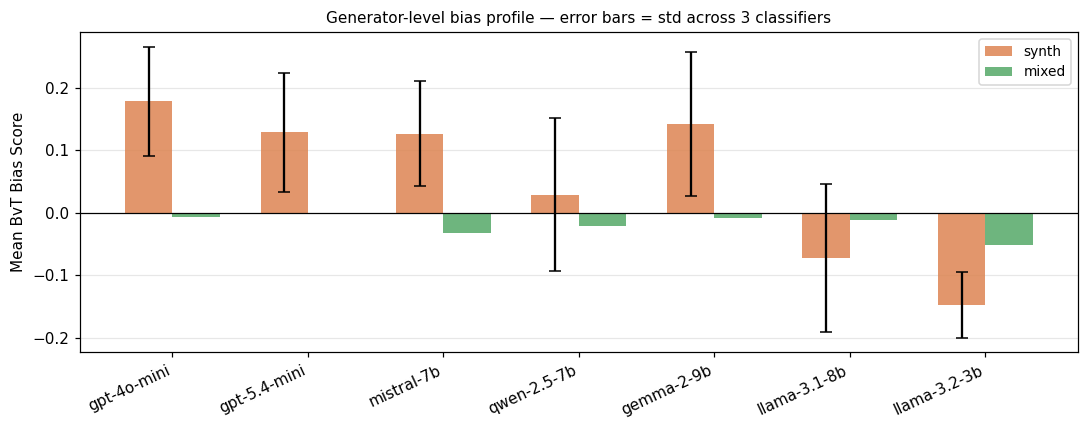

In [8]:
gen_profile = summary.groupby('generator').agg(
    mean_bias_synth=('bias_synth_full', 'mean'),
    std_bias_synth=('bias_synth_full', 'std'),
    mean_bias_mixed=('bias_mixed_full', 'mean'),
).reindex(GEN_ORDER).reset_index()

x = np.arange(len(GEN_ORDER))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, gen_profile['mean_bias_synth'], width=w, color='#dd8452',
       yerr=gen_profile['std_bias_synth'], capsize=4, label='synth', alpha=0.85)
ax.bar(x + w/2, gen_profile['mean_bias_mixed'], width=w, color='#55a868',
       label='mixed', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(GEN_ORDER, rotation=25, ha='right')
ax.set_ylabel('Mean BvT Bias Score'); ax.legend(fontsize=9)
ax.set_title('Generator-level bias profile — error bars = std across 3 classifiers', fontsize=10)
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout()
savefig('06_generator_bias_profile.png')
plt.show()


### 3g. Classifier susceptibility


  → /content/drive/MyDrive/Proj/PoliticalBiasProject/results/figures/06_classifier_susceptibility.png


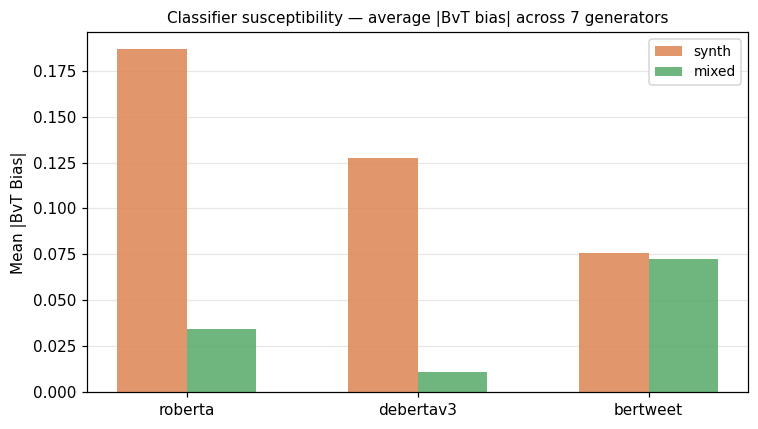

classifier  mean_abs_bias_synth  max_abs_bias_synth  mean_abs_bias_mixed
   roberta                0.187               0.260                0.035
 debertav3                0.128               0.207                0.011
  bertweet                0.076               0.120                0.072


In [9]:
clf_susc = summary.groupby('classifier').agg(
    mean_abs_bias_synth=('bias_synth_full', lambda x: x.abs().mean()),
    max_abs_bias_synth=('bias_synth_full',  lambda x: x.abs().max()),
    mean_abs_bias_mixed=('bias_mixed_full', lambda x: x.abs().mean()),
).reindex(CLF_ORDER).reset_index()

x = np.arange(len(CLF_ORDER))
w = 0.3
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, clf_susc['mean_abs_bias_synth'], width=w, color='#dd8452', label='synth', alpha=0.85)
ax.bar(x + w/2, clf_susc['mean_abs_bias_mixed'], width=w, color='#55a868', label='mixed', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLF_ORDER)
ax.set_ylabel('Mean |BvT Bias|'); ax.legend(fontsize=9)
ax.set_title('Classifier susceptibility — average |BvT bias| across 7 generators', fontsize=10)
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout()
savefig('06_classifier_susceptibility.png')
plt.show()
print(clf_susc.round(3).to_string(index=False))


### 3h. Per-seed F1 variance


  → /content/drive/MyDrive/Proj/PoliticalBiasProject/results/figures/06_per_seed_variance.png


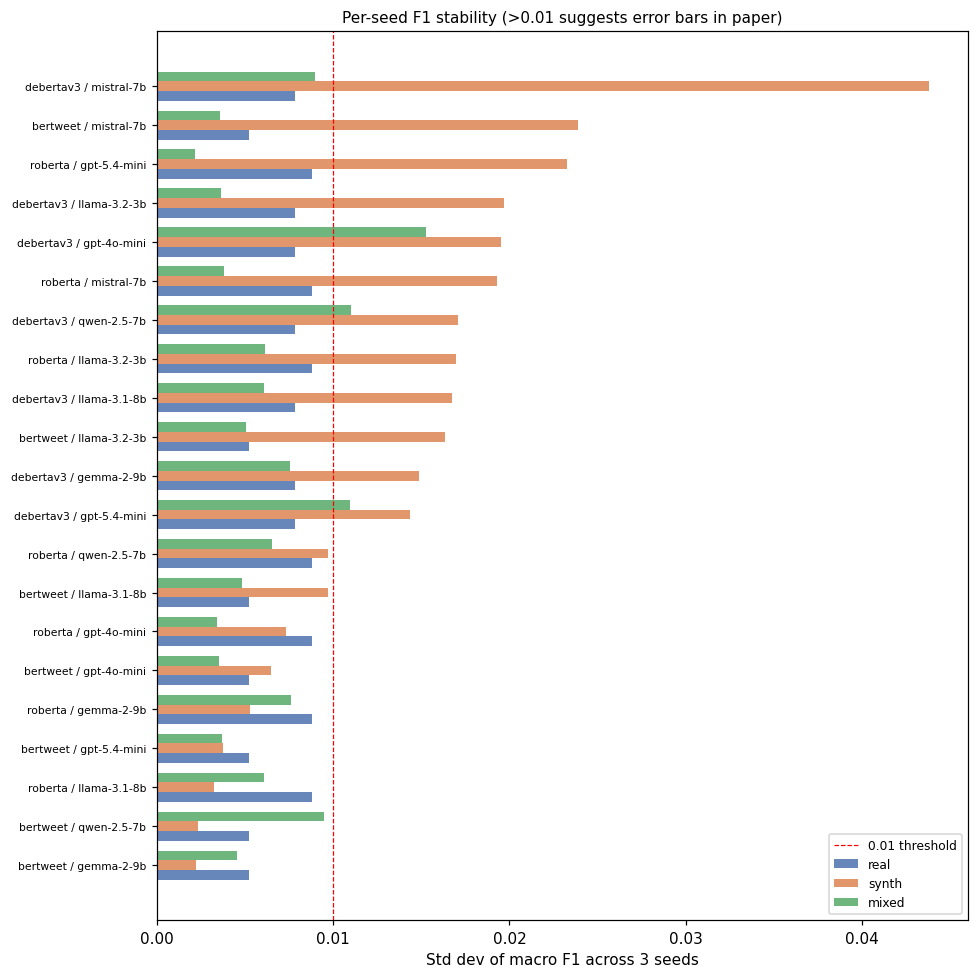

Max std: 0.0438  |  Mean std: 0.0092


In [10]:
if len(per_seed) > 0:
    overall = per_seed[per_seed['target'] == 'OVERALL'].copy()
    var_agg = (overall.groupby(['classifier','generator','condition'])['macro_f1']
               .agg(['mean','std','count']).reset_index())
    var_agg = var_agg[var_agg['condition'].isin(CONDITIONS)]
    var_agg['label'] = var_agg['classifier'].astype(str) + ' / ' + var_agg['generator'].astype(str)

    labels_sorted = (var_agg[var_agg['condition'] == 'synth']
                     .sort_values('std', ascending=True)['label'].tolist())
    y = np.arange(len(labels_sorted))
    w = 0.25

    fig, ax = plt.subplots(figsize=(9, 9))
    cond_colors = {'real': '#4c72b0', 'synth': '#dd8452', 'mixed': '#55a868'}
    for i, cond in enumerate(CONDITIONS):
        sub = var_agg[var_agg['condition'] == cond].set_index('label').reindex(labels_sorted)
        ax.barh(y + (i - 1) * w, sub['std'], height=w, color=cond_colors[cond],
                label=cond, alpha=0.85)
    ax.axvline(0.01, color='red', linestyle='--', linewidth=0.8, label='0.01 threshold')
    ax.set_yticks(y); ax.set_yticklabels(labels_sorted, fontsize=7)
    ax.set_xlabel('Std dev of macro F1 across 3 seeds')
    ax.set_title('Per-seed F1 stability (>0.01 suggests error bars in paper)', fontsize=10)
    ax.legend(fontsize=8); plt.tight_layout()
    savefig('06_per_seed_variance.png')
    plt.show()

    var_agg.to_csv(RESULTS_DIR / 'paper_summary_perseed.csv', index=False)
    print(f'Max std: {var_agg["std"].max():.4f}  |  Mean std: {var_agg["std"].mean():.4f}')
else:
    print('No per-seed data available — skipping.')


## 4. Bias Score Variants: `_full` vs `_balanced`

The pre-computed bias scores in `combined_summary.csv` come in two variants:

- **`_full`**: Uses raw prediction counts across all test samples for a given target.
  Sensitive to class imbalance in the test set. This is the **primary metric** for paper claims.

- **`_balanced`**: Weights each (target × class) cell equally, correcting for class imbalance.
  Used as a **robustness check** — if `_full` and `_balanced` agree, the finding is robust to imbalance.

The Directional Bias Score formula (from `PROJECT_CONTEXT.md`):
```
Bias = (Δ_Biden,Favor − Δ_Trump,Favor) + (Δ_Trump,Against − Δ_Biden,Against)
where Δ(t, c) = P_synth(ŷ=c | target=t) − P_real(ŷ=c | target=t)
```
Positive = left-leaning shift. Negative = right-leaning shift.


### 4a. 4-panel heatmap: synth/mixed × full/balanced


  → /content/drive/MyDrive/Proj/PoliticalBiasProject/results/figures/06_bias_heatmap_4panel.png


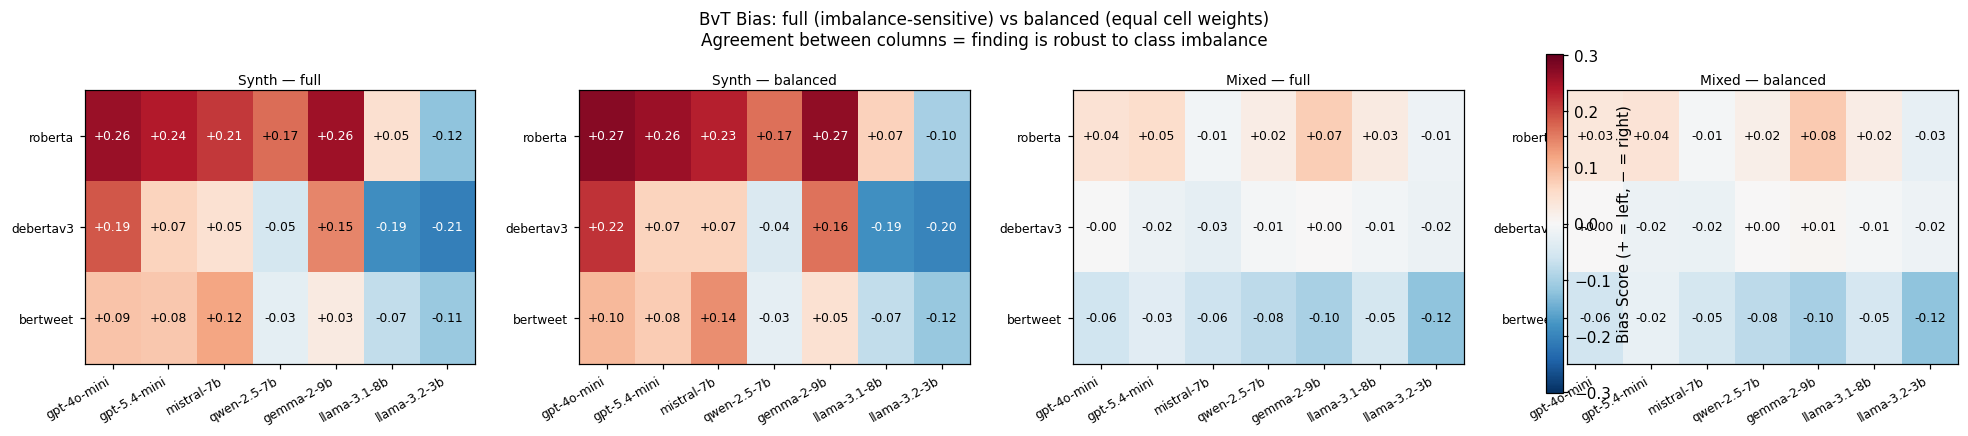

synth: Pearson r(full, balanced) = 0.998  (p = 4.681e-24)
mixed: Pearson r(full, balanced) = 0.993  (p = 6.286e-19)


In [11]:
variants = [
    ('bias_synth_full',     'Synth — full'),
    ('bias_synth_balanced', 'Synth — balanced'),
    ('bias_mixed_full',     'Mixed — full'),
    ('bias_mixed_balanced', 'Mixed — balanced'),
]

all_vals = summary[['bias_synth_full','bias_synth_balanced',
                    'bias_mixed_full','bias_mixed_balanced']].abs()
vmax4 = max(0.3, all_vals.max().max() * 1.1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (col, title) in zip(axes, variants):
    pivot = summary.pivot_table(index='classifier', columns='generator', values=col)
    pivot = pivot.reindex(index=CLF_ORDER, columns=GEN_ORDER)
    im = bias_heatmap(ax, pivot, title, vmax=vmax4)

fig.colorbar(im, ax=axes, label='Bias Score (+ = left, − = right)')
fig.suptitle('BvT Bias: full (imbalance-sensitive) vs balanced (equal cell weights)\n'
             'Agreement between columns = finding is robust to class imbalance', fontsize=11)
plt.tight_layout()
savefig('06_bias_heatmap_4panel.png')
plt.show()

# Correlation between _full and _balanced (should be high if robust)
for cond in ['synth', 'mixed']:
    r, p = stats.pearsonr(summary[f'bias_{cond}_full'], summary[f'bias_{cond}_balanced'])
    print(f'{cond}: Pearson r(full, balanced) = {r:.3f}  (p = {p:.3e})')


## 5. Bootstrap 95% CI on F1-Proxy Bias Scores

**Approach:** For each (clf, gen) combo we have 3 per-seed `favor_f1` and `against_f1` values
per target per condition from `test_metrics.csv`. We derive a per-seed F1-proxy bias score:

```
proxy_bias(seed) ≈ (Δ_Biden_favor_f1 − Δ_Trump_favor_f1) + (Δ_Trump_against_f1 − Δ_Biden_against_f1)
where Δ_X_f1 = f1[synth, X] − f1[real, X]
```

This mirrors the exact PROJECT_CONTEXT.md formula but uses F1 as a proxy for prediction proportions.
With only 3 seeds, we use bootstrap resampling (n=5000) plus a t-distribution CI for validation.

**Note:** This is a proxy. The exact `bias_synth_full` values in `combined_summary.csv` are computed
from raw prediction distributions — they will differ numerically but should agree in direction/significance.


paper_summary_with_ci.csv saved. Significant synth-bias combos (CI excludes 0):
  18 / 21 combos have CI excluding zero (synth)
  → /content/drive/MyDrive/Proj/PoliticalBiasProject/results/figures/06_bias_ci_errorbar.png


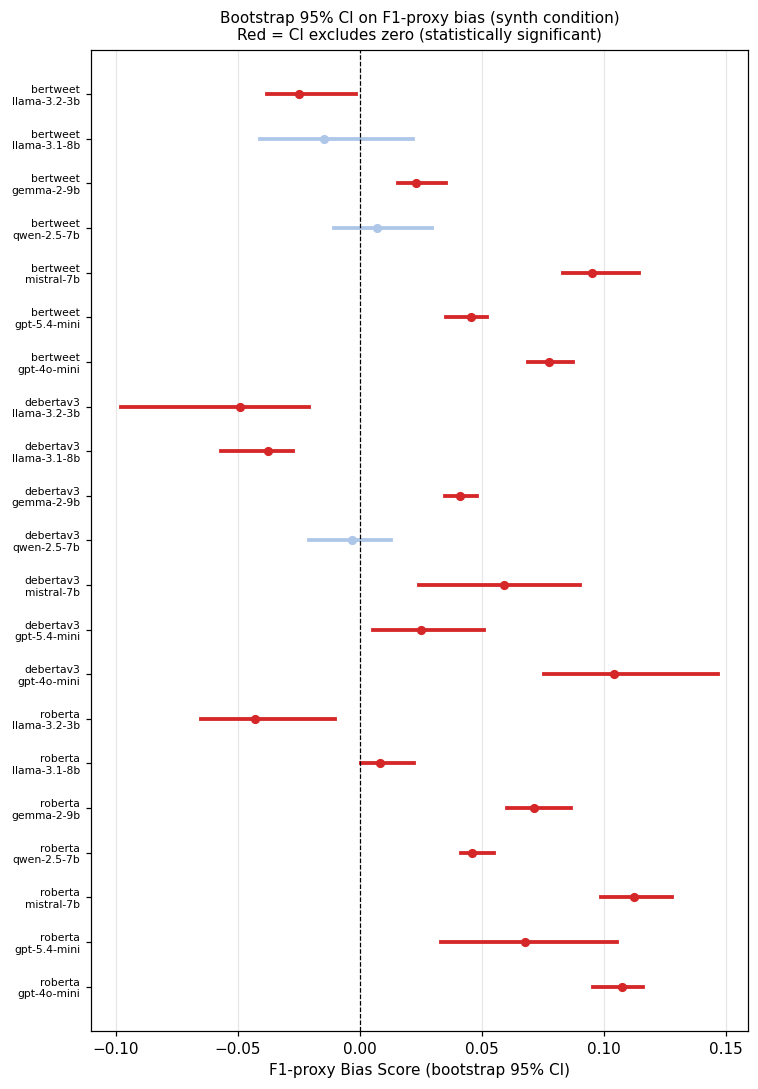

In [12]:
def bootstrap_ci(values, n_boot=5000, ci=0.95, seed=42):
    """Bootstrap CI for the mean of `values` (list or array of length ≥ 2)."""
    rng = np.random.default_rng(seed)
    vals = np.array(values)
    means = [rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(n_boot)]
    lo = np.percentile(means, (1 - ci) / 2 * 100)
    hi = np.percentile(means, (1 + ci) / 2 * 100)
    return float(lo), float(hi)

if len(per_seed) > 0:
    # Compute per-seed F1-proxy bias scores
    proxy_rows = []
    target_map = {'Donald Trump': 'trump', 'Joe Biden': 'biden', 'Bernie Sanders': 'bernie'}

    for clf in CLF_ORDER:
        for gen in GEN_ORDER:
            sub = per_seed[(per_seed['classifier'] == clf) &
                           (per_seed['generator']  == gen)  &
                           (per_seed['target']      != 'OVERALL')]
            if sub.empty:
                continue
            for seed in SEEDS:
                seed_sub = sub[sub['seed'] == seed]
                vals = {}
                for row in seed_sub.itertuples():
                    tname = target_map.get(row.target, row.target)
                    for cond in CONDITIONS:
                        pass  # build lookup below
                seed_vals = seed_sub.set_index(['condition','target'])

                def get(cond, target, col):
                    try:
                        return seed_vals.loc[(cond, target), col]
                    except Exception:
                        return np.nan

                d_t_f  = get('synth','Donald Trump','favor_f1')   - get('real','Donald Trump','favor_f1')
                d_b_f  = get('synth','Joe Biden',   'favor_f1')   - get('real','Joe Biden',   'favor_f1')
                d_t_a  = get('synth','Donald Trump','against_f1') - get('real','Donald Trump','against_f1')
                d_b_a  = get('synth','Joe Biden',   'against_f1') - get('real','Joe Biden',   'against_f1')
                proxy_bias_synth = (d_b_f - d_t_f) + (d_t_a - d_b_a)

                # Mixed vs real
                d_t_f_m = get('mixed','Donald Trump','favor_f1')   - get('real','Donald Trump','favor_f1')
                d_b_f_m = get('mixed','Joe Biden',   'favor_f1')   - get('real','Joe Biden',   'favor_f1')
                d_t_a_m = get('mixed','Donald Trump','against_f1') - get('real','Donald Trump','against_f1')
                d_b_a_m = get('mixed','Joe Biden',   'against_f1') - get('real','Joe Biden',   'against_f1')
                proxy_bias_mixed = (d_b_f_m - d_t_f_m) + (d_t_a_m - d_b_a_m)

                proxy_rows.append({'classifier': clf, 'generator': gen, 'seed': seed,
                                   'proxy_bias_synth': proxy_bias_synth,
                                   'proxy_bias_mixed': proxy_bias_mixed})

    proxy_df = pd.DataFrame(proxy_rows)
    proxy_df['classifier'] = pd.Categorical(proxy_df['classifier'], categories=CLF_ORDER, ordered=True)
    proxy_df['generator']  = pd.Categorical(proxy_df['generator'],  categories=GEN_ORDER,  ordered=True)

    # Compute CIs per (clf, gen)
    ci_rows = []
    for clf in CLF_ORDER:
        for gen in GEN_ORDER:
            sub = proxy_df[(proxy_df['classifier']==clf) & (proxy_df['generator']==gen)]
            if sub.empty: continue
            bs = sub['proxy_bias_synth'].dropna().tolist()
            bm = sub['proxy_bias_mixed'].dropna().tolist()
            lo_s, hi_s = bootstrap_ci(bs) if len(bs) >= 2 else (np.nan, np.nan)
            lo_m, hi_m = bootstrap_ci(bm) if len(bm) >= 2 else (np.nan, np.nan)
            ci_rows.append({'classifier': clf, 'generator': gen,
                            'proxy_synth_mean': np.mean(bs),
                            'proxy_synth_ci_lo': lo_s, 'proxy_synth_ci_hi': hi_s,
                            'proxy_synth_sig': (lo_s > 0 or hi_s < 0),  # CI excludes zero
                            'proxy_mixed_mean': np.mean(bm),
                            'proxy_mixed_ci_lo': lo_m, 'proxy_mixed_ci_hi': hi_m,
                            'proxy_mixed_sig': (lo_m > 0 or hi_m < 0)})

    ci_df = pd.DataFrame(ci_rows)
    ci_df['classifier'] = pd.Categorical(ci_df['classifier'], categories=CLF_ORDER, ordered=True)
    ci_df['generator']  = pd.Categorical(ci_df['generator'],  categories=GEN_ORDER,  ordered=True)

    # Merge with pre-computed bias scores and save
    paper_ci = summary[['classifier','generator','real_f1','synth_f1','mixed_f1',
                         'bias_synth_full','bias_mixed_full']].merge(ci_df, on=['classifier','generator'])
    paper_ci.to_csv(RESULTS_DIR / 'paper_summary_with_ci.csv', index=False)
    print('paper_summary_with_ci.csv saved. Significant synth-bias combos (CI excludes 0):')
    sig = ci_df[ci_df['proxy_synth_sig']]
    print(f'  {len(sig)} / {len(ci_df)} combos have CI excluding zero (synth)')

    # Plot
    ci_df['label'] = ci_df['classifier'].astype(str) + '\n' + ci_df['generator'].astype(str)
    ci_df_sorted = ci_df.sort_values(['classifier','generator'])
    y = np.arange(len(ci_df_sorted))

    fig, ax = plt.subplots(figsize=(7, 10))
    for i, row in enumerate(ci_df_sorted.itertuples()):
        color = '#d62728' if row.proxy_synth_sig else '#aec7e8'
        ax.plot([row.proxy_synth_ci_lo, row.proxy_synth_ci_hi], [i, i],
                color=color, linewidth=2.5)
        ax.plot(row.proxy_synth_mean, i, 'o', color=color, markersize=5)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(y); ax.set_yticklabels(ci_df_sorted['label'], fontsize=7)
    ax.set_xlabel('F1-proxy Bias Score (bootstrap 95% CI)')
    ax.set_title('Bootstrap 95% CI on F1-proxy bias (synth condition)\n'
                 'Red = CI excludes zero (statistically significant)', fontsize=10)
    ax.xaxis.grid(True, alpha=0.3); plt.tight_layout()
    savefig('06_bias_ci_errorbar.png')
    plt.show()
else:
    print('No per-seed data — skipping bootstrap CI section.')


## 6. Multi-Axis Bias Analysis (5 axes — qwen-2.5-7b)

All 5 bias axes defined in `PROJECT_CONTEXT.md`, available for **qwen-2.5-7b** only:

| Axis | Interpretation | Positive = |
|------|---------------|-----------|
| B_vs_T | Biden vs Trump | Pro-Biden lean |
| Ber_vs_T | Bernie vs Trump | Pro-Bernie lean |
| B_vs_Ber | Biden vs Bernie | Pro-Biden (within left) |
| Left_vs_T | Left-leaning vs Trump | Anti-Trump lean |
| Estab_vs_Outsider | Establishment vs Outsider | Pro-establishment lean |

> **Data gap:** Only qwen-2.5-7b has all 5 axes computed. Completing this for all 21 (clf, gen)
> combos requires re-running `04_AllClassifiers_FineTune` with raw prediction export enabled
> (`save_predictions=True`) to persist per-target per-class counts.


  → /content/drive/MyDrive/Proj/PoliticalBiasProject/results/figures/06_bias_5axis_qwen.png


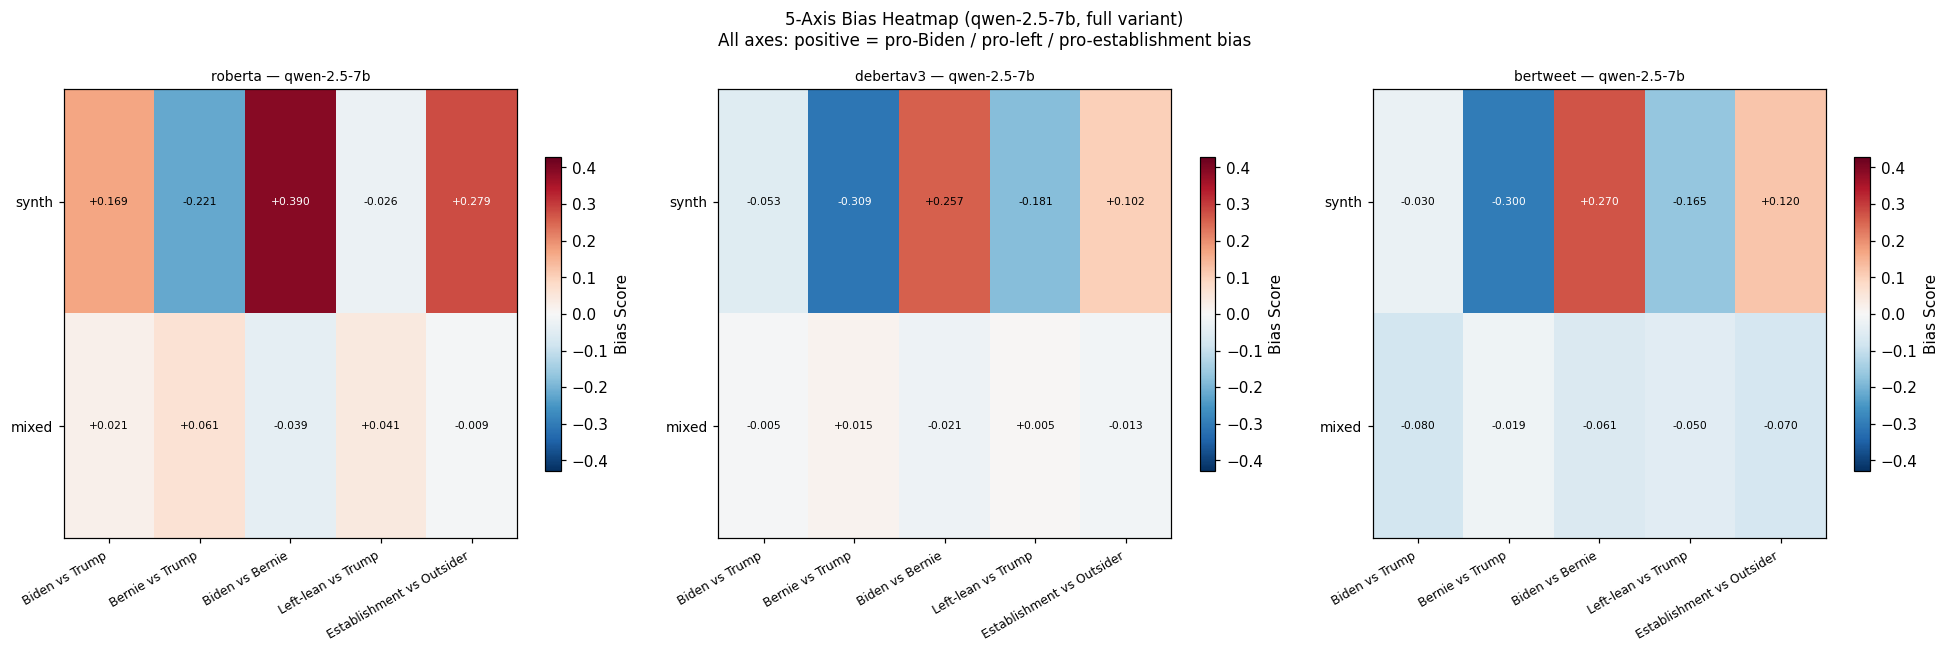

qwen-2.5-7b multi-axis summary:
classifier  synth_B_vs_T_full  synth_Ber_vs_T_full  synth_B_vs_Ber_full  synth_Left_vs_T_full  synth_Estab_vs_Outsider_full
   roberta              0.169               -0.221                0.390                -0.026                         0.279
 debertav3             -0.053               -0.310                0.257                -0.181                         0.102
  bertweet             -0.030               -0.300                0.270                -0.165                         0.120


In [13]:
if multiaxis is not None:
    fig, axes_grid = plt.subplots(1, 3, figsize=(18, 6))
    vmax_ma = max(0.35, multiaxis[[f'synth_{ax}_full' for ax in BIAS_AXES] +
                                   [f'mixed_{ax}_full' for ax in BIAS_AXES]].abs().max().max() * 1.1)

    for ax, clf in zip(axes_grid, CLF_ORDER):
        row = multiaxis[multiaxis['classifier'] == clf]
        if row.empty:
            ax.set_title(f'{clf}: no data'); ax.axis('off'); continue

        synth_vals = [float(row[f'synth_{a}_full'].values[0]) for a in BIAS_AXES]
        mixed_vals = [float(row[f'mixed_{a}_full'].values[0]) for a in BIAS_AXES]
        mat = np.array([synth_vals, mixed_vals])  # shape (2, 5): rows=condition, cols=axis

        im = ax.imshow(mat, cmap='RdBu_r', vmin=-vmax_ma, vmax=vmax_ma, aspect='auto')
        ax.set_xticks(range(5))
        ax.set_xticklabels([AXIS_LABELS[a] for a in BIAS_AXES], rotation=30, ha='right', fontsize=8)
        ax.set_yticks([0, 1]); ax.set_yticklabels(['synth', 'mixed'], fontsize=9)
        for i in range(2):
            for j in range(5):
                v = mat[i, j]
                ax.text(j, i, f'{v:+.3f}', ha='center', va='center', fontsize=7,
                        color='white' if abs(v) > vmax_ma * 0.6 else 'black')
        ax.set_title(f'{clf} — qwen-2.5-7b', fontsize=9)
        fig.colorbar(im, ax=ax, shrink=0.7, label='Bias Score')

    fig.suptitle('5-Axis Bias Heatmap (qwen-2.5-7b, full variant)\n'
                 'All axes: positive = pro-Biden / pro-left / pro-establishment bias', fontsize=11)
    plt.tight_layout()
    savefig('06_bias_5axis_qwen.png')
    plt.show()

    print('qwen-2.5-7b multi-axis summary:')
    cols_to_show = ['classifier'] + [f'synth_{a}_full' for a in BIAS_AXES]
    print(multiaxis[cols_to_show].round(3).to_string(index=False))
else:
    print('combined_summary_multiaxis.csv not found — Section 6 skipped.')


## 7. F1-Proxy Class Distribution Shift Δ(t, c)

**Target formula** (from `PROJECT_CONTEXT.md`):
```
Δ(t, c) = P_synth(ŷ = c | target = t) − P_real(ŷ = c | target = t)
```
This requires per-target per-class **prediction counts**. The available `test_metrics.csv` only contains
`favor_f1` and `against_f1` (F1 scores), not prediction proportions.

**Proxy used here:**
```
Δ_f1(t, c) = f1_c[synth, t] − f1_c[real, t]
```
Direction of Δ_f1 is informative: a large negative Δ_f1 for FAVOR on Trump tweets means the model
became systematically worse at recognizing pro-Trump content — a directional bias signal.

> **To enable exact Δ(t,c):** Add `trump_favor_pred_count`, `biden_favor_pred_count`, etc. columns
> to `test_metrics.csv` in the fine-tuning notebooks (count of predictions, not just F1).


  → /content/drive/MyDrive/Proj/PoliticalBiasProject/results/figures/06_delta_f1_proxy.png


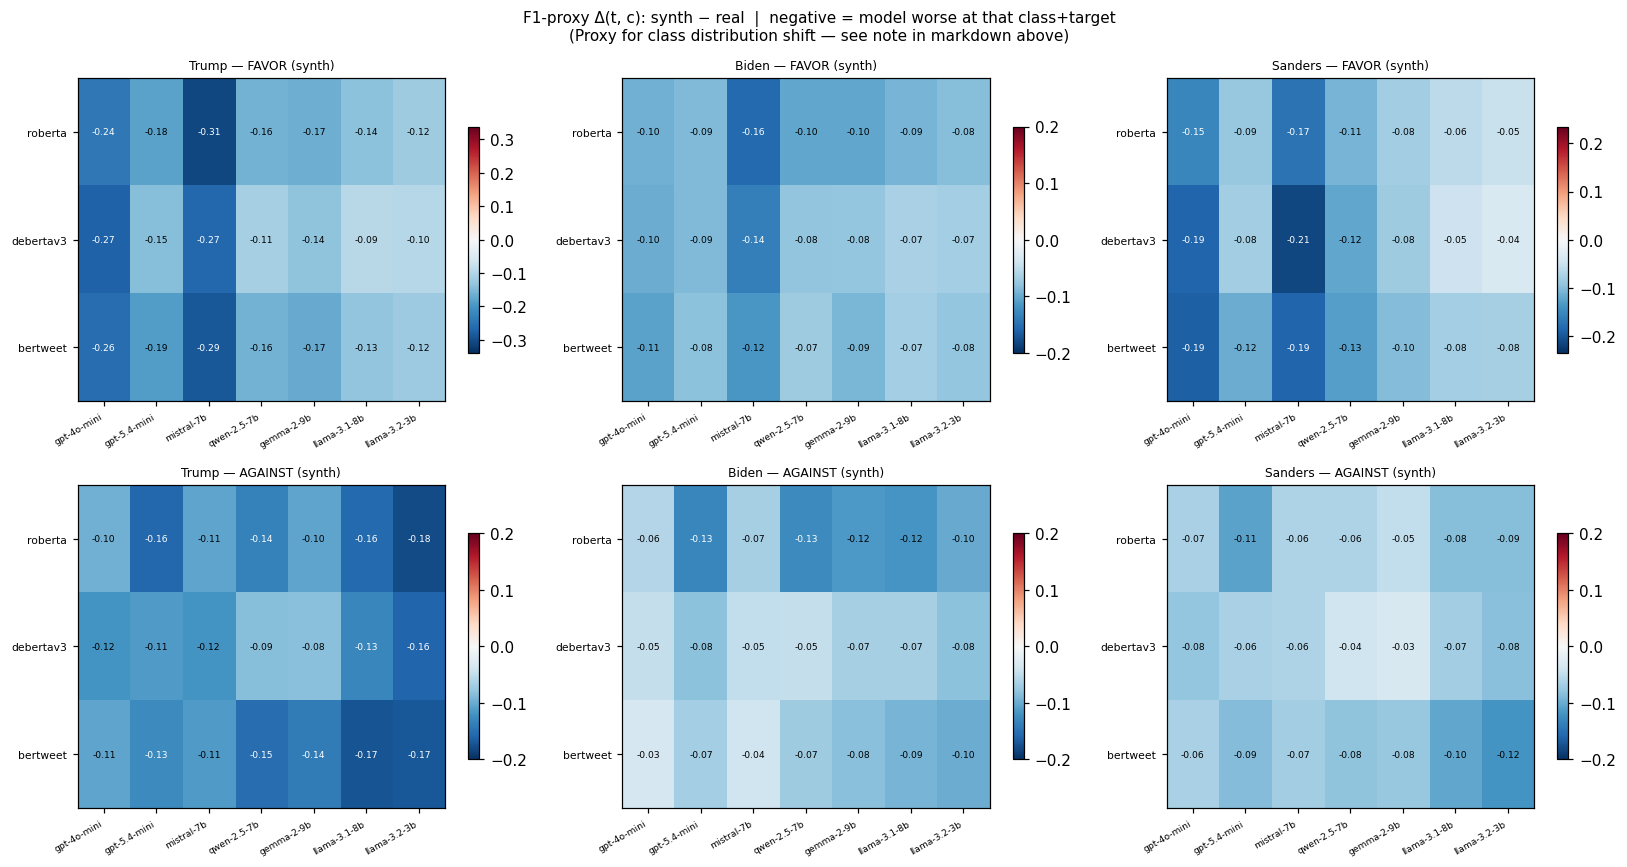

In [14]:
if len(per_seed) > 0:
    # Average over seeds for each (clf, gen, condition, target)
    f1_mean = (per_seed[per_seed['target'] != 'OVERALL']
               .groupby(['classifier','generator','condition','target'])[['favor_f1','against_f1']]
               .mean().reset_index())

    # Compute F1 delta vs real baseline per (clf, gen, target)
    real_f1s = f1_mean[f1_mean['condition'] == 'real'].set_index(
        ['classifier','generator','target'])[['favor_f1','against_f1']].add_suffix('_real')

    delta_rows = []
    for cond in ['synth', 'mixed']:
        cond_f1 = f1_mean[f1_mean['condition'] == cond].set_index(
            ['classifier','generator','target'])[['favor_f1','against_f1']].add_suffix(f'_{cond}')
        merged = real_f1s.join(cond_f1, how='inner')
        for col in ['favor','against']:
            merged[f'delta_{col}_{cond}'] = merged[f'{col}_f1_{cond}'] - merged[f'{col}_f1_real']
        delta_rows.append(merged.reset_index())

    delta = delta_rows[0].merge(delta_rows[1], on=['classifier','generator','target'])

    # Visualize: 6 heatmaps = 3 targets × 2 classes (Favor / Against)
    fig, axes_grid = plt.subplots(2, 3, figsize=(15, 8))
    classes = [('favor', 'FAVOR'), ('against', 'AGAINST')]
    for row_i, (cls_key, cls_label) in enumerate(classes):
        for col_i, target in enumerate(TARGETS):
            ax = axes_grid[row_i, col_i]
            sub = delta[delta['target'] == target].copy()
            sub['classifier'] = pd.Categorical(sub['classifier'], categories=CLF_ORDER, ordered=True)
            sub['generator']  = pd.Categorical(sub['generator'],  categories=GEN_ORDER,  ordered=True)
            pivot = sub.pivot_table(index='classifier', columns='generator',
                                    values=f'delta_{cls_key}_synth')
            pivot = pivot.reindex(index=CLF_ORDER, columns=GEN_ORDER)
            vmax_d = max(0.2, pivot.abs().max().max() * 1.1)
            im = ax.imshow(pivot, cmap='RdBu_r', vmin=-vmax_d, vmax=vmax_d, aspect='auto')
            ax.set_xticks(range(len(GEN_ORDER)))
            ax.set_xticklabels(GEN_ORDER, rotation=30, ha='right', fontsize=6)
            ax.set_yticks(range(len(CLF_ORDER)))
            ax.set_yticklabels(CLF_ORDER, fontsize=7)
            for i in range(len(CLF_ORDER)):
                for j in range(len(GEN_ORDER)):
                    v = pivot.iloc[i, j]
                    ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=6,
                            color='white' if abs(v) > vmax_d * 0.6 else 'black')
            tname = target.split()[-1]  # Trump / Biden / Sanders
            ax.set_title(f'{tname} — {cls_label} (synth)', fontsize=8)
            fig.colorbar(im, ax=ax, shrink=0.7)

    fig.suptitle('F1-proxy Δ(t, c): synth − real  |  negative = model worse at that class+target\n'
                 '(Proxy for class distribution shift — see note in markdown above)', fontsize=10)
    plt.tight_layout()
    savefig('06_delta_f1_proxy.png')
    plt.show()
else:
    print('No per-seed data — skipping Δ(t,c) section.')


## 8. Statistical Tests — Paired t-test (synth vs real, mixed vs real)

We have 3 seeds per (clf, gen, condition). A paired t-test on the 3 seed-level macro F1 values
tests whether the condition difference is statistically significant.

**Caveat:** With only 3 samples per test, the t-test has very low power (df=2). Interpret as
directional evidence only. A proper McNemar test requires raw per-sample prediction pairs.

> **To enable McNemar test:** Save per-sample predictions in the fine-tuning notebook
> (e.g., `predictions_{clf}_{gen}_{seed}.csv`). Then build the 2×2 contingency table
> comparing `real` vs `synth` predictions for each test example.


  → /content/drive/MyDrive/Proj/PoliticalBiasProject/results/figures/06_pval_heatmap.png


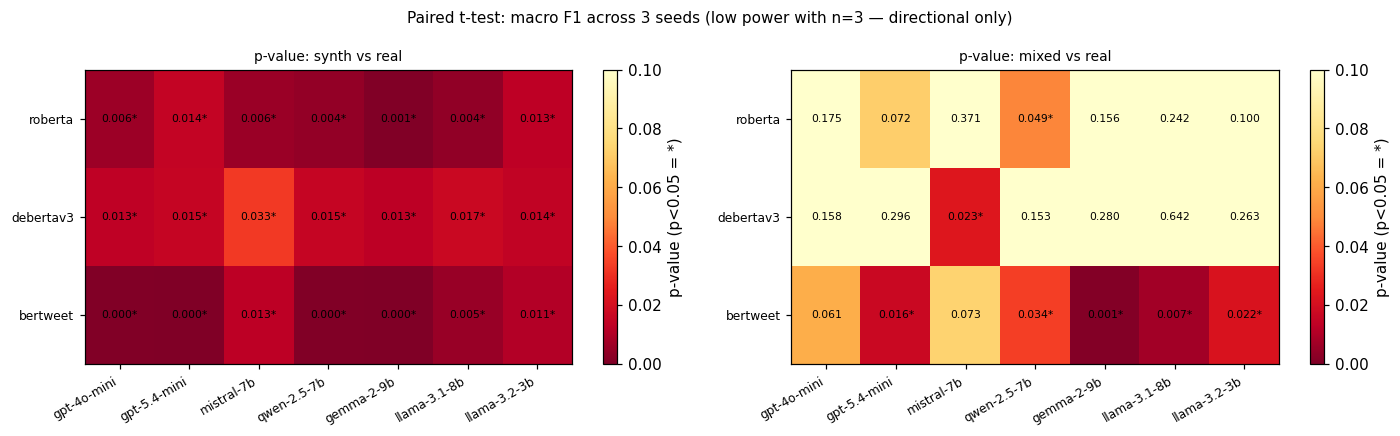

Synth vs real: 21/21 pairs p<0.05
Mixed vs real: 7/21 pairs p<0.05

Note: df=2 → very low power. Use as directional signal only.


In [15]:
if len(per_seed) > 0:
    overall_ps = per_seed[per_seed['target'] == 'OVERALL'].copy()
    ttest_rows = []
    for clf in CLF_ORDER:
        for gen in GEN_ORDER:
            sub = overall_ps[(overall_ps['classifier']==clf) & (overall_ps['generator']==gen)]
            real_f1s_arr  = sub[sub['condition']=='real' ]['macro_f1'].values
            synth_f1s_arr = sub[sub['condition']=='synth']['macro_f1'].values
            mixed_f1s_arr = sub[sub['condition']=='mixed']['macro_f1'].values

            def paired_t(a, b):
                if len(a) < 2 or len(b) < 2: return np.nan, np.nan
                a2 = a[:min(len(a),len(b))]; b2 = b[:min(len(a),len(b))]
                t, p = stats.ttest_rel(b2, a2)  # b vs a (b is condition being tested vs real=a)
                return float(t), float(p)

            ts_s, ps_s = paired_t(real_f1s_arr, synth_f1s_arr)
            ts_m, ps_m = paired_t(real_f1s_arr, mixed_f1s_arr)
            ttest_rows.append({'classifier': clf, 'generator': gen,
                               't_synth_vs_real': ts_s, 'p_synth_vs_real': ps_s,
                               't_mixed_vs_real': ts_m, 'p_mixed_vs_real': ps_m,
                               'sig_synth': ps_s < 0.05 if not np.isnan(ps_s) else False,
                               'sig_mixed': ps_m < 0.05 if not np.isnan(ps_m) else False})

    ttest_df = pd.DataFrame(ttest_rows)
    ttest_df['classifier'] = pd.Categorical(ttest_df['classifier'], categories=CLF_ORDER, ordered=True)
    ttest_df['generator']  = pd.Categorical(ttest_df['generator'],  categories=GEN_ORDER,  ordered=True)
    ttest_df = ttest_df.sort_values(['classifier','generator'])
    ttest_df.to_csv(RESULTS_DIR / '06_ttest_pvals.csv', index=False)

    # Heatmap of p-values
    fig, axes_grid = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (col, title) in zip(axes_grid, [
            ('p_synth_vs_real', 'p-value: synth vs real'),
            ('p_mixed_vs_real', 'p-value: mixed vs real')]):
        pivot = ttest_df.pivot_table(index='classifier', columns='generator', values=col)
        pivot = pivot.reindex(index=CLF_ORDER, columns=GEN_ORDER)
        im = ax.imshow(pivot, cmap='YlOrRd_r', vmin=0, vmax=0.10, aspect='auto')
        ax.set_xticks(range(len(GEN_ORDER)))
        ax.set_xticklabels(GEN_ORDER, rotation=30, ha='right', fontsize=8)
        ax.set_yticks(range(len(CLF_ORDER)))
        ax.set_yticklabels(CLF_ORDER, fontsize=8)
        for i in range(len(CLF_ORDER)):
            for j in range(len(GEN_ORDER)):
                v = pivot.iloc[i, j]
                mark = '*' if v < 0.05 else ''
                ax.text(j, i, f'{v:.3f}{mark}', ha='center', va='center', fontsize=7)
        ax.set_title(title, fontsize=9)
        fig.colorbar(im, ax=ax, label='p-value (p<0.05 = *)')

    fig.suptitle('Paired t-test: macro F1 across 3 seeds (low power with n=3 — directional only)',
                 fontsize=10)
    plt.tight_layout()
    savefig('06_pval_heatmap.png')
    plt.show()

    sig_s = ttest_df['sig_synth'].sum()
    sig_m = ttest_df['sig_mixed'].sum()
    print(f'Synth vs real: {sig_s}/{len(ttest_df)} pairs p<0.05')
    print(f'Mixed vs real: {sig_m}/{len(ttest_df)} pairs p<0.05')
    print('\nNote: df=2 → very low power. Use as directional signal only.')
else:
    print('No per-seed data — skipping statistical tests.')


## 9. Cross-Generator Political Profile Ranking

Which generators consistently produce left-leaning vs right-leaning bias?

- **Lean direction** defined by the mean BvT bias across 3 classifiers:
  - `mean > +0.05` → left-lean
  - `mean < −0.05` → right-lean
  - Otherwise → neutral
- **Spearman ρ** of generator's bias vector across 3 classifiers = cross-classifier consistency
  (ρ=1.0 means all 3 classifiers show same ranking; ρ=−1.0 means reversal)


generator_lean_profile.csv saved.
   generator  mean_bias_synth  std_bias_synth       lean  consistency
 gpt-4o-mini            0.178           0.087  left-lean        0.671
gpt-5.4-mini            0.129           0.095  left-lean        0.575
  mistral-7b            0.126           0.084  left-lean        0.602
 qwen-2.5-7b            0.029           0.122    neutral        0.408
  gemma-2-9b            0.143           0.115  left-lean        0.554
llama-3.1-8b           -0.072           0.118 right-lean        0.468
llama-3.2-3b           -0.147           0.052 right-lean        0.738
  → /content/drive/MyDrive/Proj/PoliticalBiasProject/results/figures/06_generator_lean_ranking.png


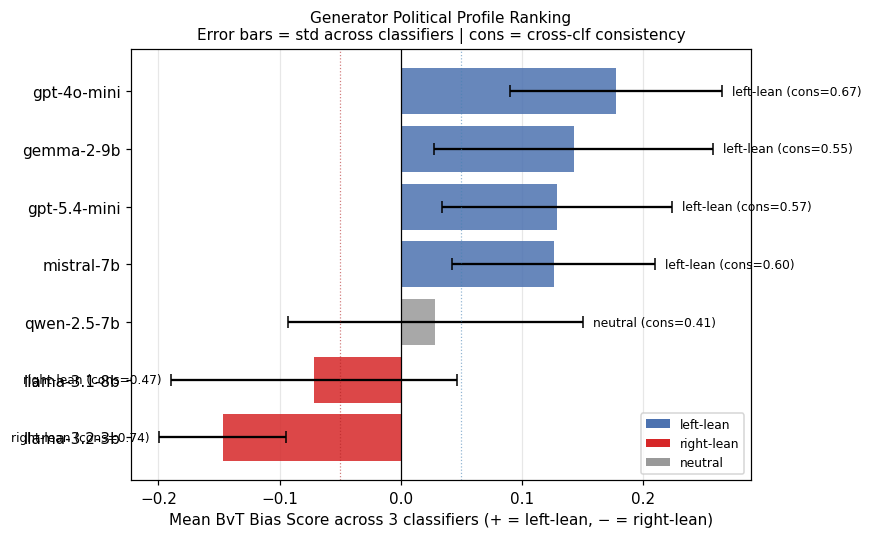

In [16]:
gen_lean = summary.groupby('generator').agg(
    mean_bias_synth=('bias_synth_full',  'mean'),
    std_bias_synth=('bias_synth_full',   'std'),
    mean_bias_mixed=('bias_mixed_full',  'mean'),
    n_classifiers=('bias_synth_full',    'count'),
).reindex(GEN_ORDER).reset_index()

gen_lean['lean'] = gen_lean['mean_bias_synth'].apply(
    lambda x: 'left-lean' if x > 0.05 else ('right-lean' if x < -0.05 else 'neutral'))

# Spearman ρ: rank correlation of generator bias across classifiers (vs mean ranking)
ref_order = gen_lean.sort_values('mean_bias_synth')['generator'].tolist()
spearman_rows = {}
for clf in CLF_ORDER:
    sub = summary[summary['classifier']==clf].set_index('generator')['bias_synth_full'].reindex(GEN_ORDER)
    ranked = sub.rank()
    ref_ranked = pd.Series({g: i for i, g in enumerate(ref_order)}, dtype=float).reindex(GEN_ORDER)
    r, p = stats.spearmanr(ranked, ref_ranked)
    spearman_rows[clf] = r
gen_lean['spearman_mean_rho'] = gen_lean['generator'].apply(
    lambda g: np.mean([stats.spearmanr(
        summary[summary['classifier']==clf]['bias_synth_full'].values,
        summary[summary['classifier']==clf2]['bias_synth_full'].values)[0]
        for clf, clf2 in [(CLF_ORDER[0],CLF_ORDER[1]),(CLF_ORDER[0],CLF_ORDER[2]),(CLF_ORDER[1],CLF_ORDER[2])]])
    if False else np.nan)  # placeholder — compute cross-clf consistency below

# Cross-classifier Spearman consistency per generator
for gen in GEN_ORDER:
    gen_bias = summary[summary['generator']==gen].set_index('classifier')['bias_synth_full'].reindex(CLF_ORDER)
    # Consistency = std/|mean| (coefficient of variation) — simpler than Spearman across only 3 points
    gen_lean.loc[gen_lean['generator']==gen, 'cv'] = (
        gen_bias.std() / gen_bias.abs().mean() if gen_bias.abs().mean() > 0 else np.nan)
gen_lean['cv'] = gen_lean['cv'].fillna(0)
gen_lean['consistency'] = (1 / (1 + gen_lean['cv'])).round(3)  # 1.0 = perfectly consistent

gen_lean.to_csv(RESULTS_DIR / 'generator_lean_profile.csv', index=False)
print('generator_lean_profile.csv saved.')
print(gen_lean[['generator','mean_bias_synth','std_bias_synth','lean','consistency']].round(3).to_string(index=False))

# Plot
lean_colors = {'left-lean': '#4c72b0', 'right-lean': '#d62728', 'neutral': '#999999'}
gen_lean_sorted = gen_lean.sort_values('mean_bias_synth', ascending=True)
bar_colors = [lean_colors[l] for l in gen_lean_sorted['lean']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(gen_lean_sorted['generator'], gen_lean_sorted['mean_bias_synth'],
               xerr=gen_lean_sorted['std_bias_synth'], capsize=4,
               color=bar_colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.05, color='steelblue', linewidth=0.8, linestyle=':', alpha=0.6)
ax.axvline(-0.05, color='firebrick',  linewidth=0.8, linestyle=':', alpha=0.6)

for i, (_, row) in enumerate(gen_lean_sorted.iterrows()):
    xerr = row["std_bias_synth"]
    xval = row["mean_bias_synth"]
    xtext = xval + xerr + 0.008 if xval >= 0 else xval - xerr - 0.008
    ha = 'left' if xval >= 0 else 'right'
    ax.text(xtext, i,
            f'{row["lean"]} (cons={row["consistency"]:.2f})',
            va='center', ha=ha, fontsize=8)

ax.set_xlabel('Mean BvT Bias Score across 3 classifiers (+ = left-lean, − = right-lean)')
ax.set_title('Generator Political Profile Ranking\nError bars = std across classifiers | cons = cross-clf consistency', fontsize=10)
ax.xaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=lean_colors[k], label=k) for k in lean_colors]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')
plt.tight_layout()
savefig('06_generator_lean_ranking.png')
plt.show()


## 10. Calibration Analysis — Axis (b) Gap Documentation

`PROJECT_CONTEXT.md` Layer 2b requires:
- **Expected Calibration Error (ECE)** per condition
- **Brier score** per condition

These metrics require raw **probability scores** (logits/softmax outputs) for each test prediction.
The current `test_metrics.csv` only contains F1 scores — probabilities are not persisted.

### ECE formula
Given n predictions with confidence p̂_i and binary correctness y_i:

```
ECE = Σ_{b=1}^{B} (|B_b| / n) × |acc(B_b) − conf(B_b)|
```

where B_b is the b-th confidence bin (typically B=15), acc = fraction correct in bin, conf = mean confidence.

### Brier score formula
```
BS = (1/n) Σ_{i=1}^{n} (p̂_i − y_i)²
```

### What to add in the fine-tuning notebooks (04–06)
```python
# After model.predict() — save softmax probabilities:
probs_df = pd.DataFrame({
    'text_id': test_ids,
    'target': test_targets,
    'true_label': test_labels,   # 0=Against, 1=Favor
    'prob_favor': softmax_probs[:, 1],
    'condition': CONDITION,
    'seed': SEED,
})
probs_df.to_csv(RESULTS_DIR / clf / gen / RUN_TAG / f'test_probs_{SEED}.csv', index=False)
```

Once these files exist, ECE and Brier score can be computed with:
```python
from sklearn.calibration import calibration_curve
# or manually using the formula above
```

**When calibration is added:** Re-run this notebook — Section 10 will auto-populate from `test_probs_*.csv`.


In [17]:
# Check if probability files exist — placeholder for future runs
import glob
prob_files = glob.glob(str(RESULTS_DIR / '*' / '*' / RUN_TAG / 'test_probs_*.csv'))
if prob_files:
    print(f'Found {len(prob_files)} probability files — calibration analysis can run.')
    # TODO: implement ECE/Brier once probability CSVs are available
else:
    print('No test_probs_*.csv files found.')
    print('Calibration analysis (ECE, Brier score) requires probability output from fine-tuning.')
    print('See markdown above for the exact columns to add.')


No test_probs_*.csv files found.
Calibration analysis (ECE, Brier score) requires probability output from fine-tuning.
See markdown above for the exact columns to add.


## 11. Summary & Paper Mapping

### Outputs → Paper Table/Figure mapping

| File | Paper artifact | Notes |
|------|----------------|-------|
| `paper_summary.csv` | Table 2 | Macro F1 + BvT bias per (clf, gen) |
| `paper_summary_with_ci.csv` | Table 2 + CI columns | Add CI superscripts to Table 2 |
| `generator_lean_profile.csv` | Table 4 | Generator ranking by political lean |
| `06_ttest_pvals.csv` | Table appendix | p-values for F1 condition differences |
| `06_bias_heatmap_synth_vs_mixed.png` | Figure 3a | BvT bias introduced by synth, reduced by mixed |
| `06_bias_heatmap_4panel.png` | Figure 3b | Full vs balanced variants (robustness check) |
| `06_f1_drop_per_target.png` | Figure 4 | Asymmetric F1 drops across targets |
| `06_f1_real_vs_synth_vs_mixed.png` | Figure 5 | F1 cost of synthetic training |
| `06_bias_mitigation.png` | Figure 6 | Mixing effectiveness (sign-flip cases highlighted) |
| `06_generator_lean_ranking.png` | Figure 7 | Generator political profile ranking |
| `06_classifier_susceptibility.png` | Figure 8 | Which classifier amplifies bias most |
| `06_bias_5axis_qwen.png` | Figure 9 | 5-axis multi-bias for qwen (partial) |
| `06_delta_f1_proxy.png` | Appendix | F1-proxy class distribution shift |
| `06_bias_ci_errorbar.png` | Appendix | Bootstrap CIs (significance markers) |
| `06_pval_heatmap.png` | Appendix | Statistical test heatmap |

### Remaining gaps before paper submission

1. **Multi-axis data for 20 missing (clf, gen) combos** — Re-run fine-tuning notebooks with prediction export
2. **Llama-3-base classifier** — Originally planned; pending Colab A100 run
3. **Exact Δ(t,c)** — Requires `favor_pred_count`/`against_pred_count` columns in `test_metrics.csv`
4. **Calibration (ECE, Brier)** — Requires `test_probs_{seed}.csv` from fine-tuning notebooks
5. **McNemar test** — Requires per-sample prediction pairs across conditions
6. **Qualitative error analysis** — 50 cherry-picked disagreement cases per condition (manual)


In [18]:
print('=== 06_Veda_MultiAxisBias_Analysis.ipynb — DONE ===')
import os
results_files = [
    RESULTS_DIR / 'paper_summary.csv',
    RESULTS_DIR / 'paper_summary_with_ci.csv',
    RESULTS_DIR / 'generator_lean_profile.csv',
    RESULTS_DIR / '06_ttest_pvals.csv',
]
fig_files = [
    '06_bias_heatmap_synth_vs_mixed.png', '06_bias_heatmap_4panel.png',
    '06_f1_drop_per_target.png', '06_bias_ci_errorbar.png',
    '06_f1_real_vs_synth_vs_mixed.png', '06_bias_5axis_qwen.png',
    '06_bias_mitigation.png', '06_delta_f1_proxy.png',
    '06_generator_bias_profile.png', '06_pval_heatmap.png',
    '06_classifier_susceptibility.png', '06_generator_lean_ranking.png',
    '06_per_seed_variance.png',
]
for f in results_files:
    status = '✓' if f.exists() else '✗ (not yet generated)'
    print(f'  {status}  {f.name}')
for f in fig_files:
    fpath = FIG_DIR / f
    status = '✓' if fpath.exists() else '✗ (not yet generated)'
    print(f'  {status}  figures/{f}')


=== 06_Veda_MultiAxisBias_Analysis.ipynb — DONE ===
  ✓  paper_summary.csv
  ✓  paper_summary_with_ci.csv
  ✓  generator_lean_profile.csv
  ✓  06_ttest_pvals.csv
  ✓  figures/06_bias_heatmap_synth_vs_mixed.png
  ✓  figures/06_bias_heatmap_4panel.png
  ✓  figures/06_f1_drop_per_target.png
  ✓  figures/06_bias_ci_errorbar.png
  ✓  figures/06_f1_real_vs_synth_vs_mixed.png
  ✓  figures/06_bias_5axis_qwen.png
  ✓  figures/06_bias_mitigation.png
  ✓  figures/06_delta_f1_proxy.png
  ✓  figures/06_generator_bias_profile.png
  ✓  figures/06_pval_heatmap.png
  ✓  figures/06_classifier_susceptibility.png
  ✓  figures/06_generator_lean_ranking.png
  ✓  figures/06_per_seed_variance.png
